In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt 
import numpy as np 
import time 
import os
import sys
import pandas as pd 
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
from sklearn.datasets import make_moons
torch.set_default_dtype(torch.float32)
datatype=torch.float32

In [3]:
# Generate the dataset
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)

# Convert to PyTorch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y,dtype=torch.float32)#torch.set_default_dtype(torch.float32)

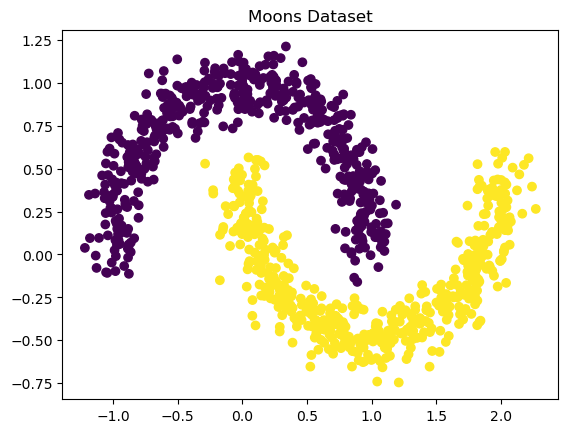

In [4]:
### The point being that we don't need the label color but the X coordinates. 
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.title("Moons Dataset")
plt.show()

In [5]:
class SDE1(object):
    def __init__(self,N,Xdata): 
        """
        x1-- the terminal variable
        a-- the initial variable
        x--  the input variable
        N -- the total number timesteps
        """
        self.X1=Xdata; 
        self.N=N 
        self.dt=torch.tensor(1.0/N)
        self.d=self.X1.shape[1]

    def sigma2VE(self, t): 
        sig=t
        return sig

    def sigmaDiff(self,t):
        siguD=torch.tensor(1.0)
        return siguD

    def ftVE(self,x1,a,x,t): 
        ## alpha_0=0.0
        num=self.sigma2VE(t)
        ft_xx1=torch.exp(torch.sum((x1-a)**2, axis=1)/(2.0) -torch.sum((x1-x)**2,axis=1)/(2.0-2.0*num))
        ## This provides a weight vector
        return ft_xx1.unsqueeze(1)

    def uVE(self,a,X1,x,t): 
        ## defining the numerator
        num=torch.mean((X1-x)*self.ftVE(X1,a,x,t),axis=0)
        ## defining the denominator
        deno=torch.mean(self.ftVE(X1,a,x,t),axis=0)*(1.0-self.sigma2VE(t))
        return num/deno

    def forward(self,a):
        ## we just want the terminal x1.
        ## a can be the [0,0] vector. 
        Xt=a.clone()
        
        ### simulating the SDE trajectory by trajectory. 
        t=torch.tensor(0.0)
        for i in range(self.N): 
            Xt=Xt+self.dt*self.uVE(a,self.X1,Xt,t)+torch.randn_like(Xt)*torch.sqrt(self.dt)#*self.sigmaDiff(t)
            t=t+self.dt
        return Xt


In [6]:
N=100;
sde=SDE1(N,X)

In [7]:
x0=torch.zeros(2)
M=800;
Xlist=list()
for i in range(M):
    xx1=sde.forward(x0)
    Xlist.append(xx1)

Text(0.5, 1.0, 'Moons Dataset')

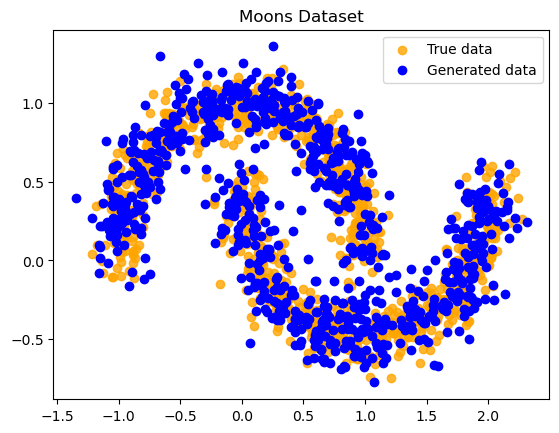

In [8]:
Xg=torch.stack(Xlist)
plt.scatter(X[:, 0], X[:, 1],alpha=0.8,color='orange')
plt.scatter(Xg[:, 0], Xg[:, 1],color='blue')
plt.legend(['True data','Generated data'])
plt.title("Moons Dataset")
#plt.savefig('moons_ensemble400_N1024.png')

# Regularized SDE

In [9]:
eps=1e-6 

class SDE_eps(object):
    def __init__(self,N,Xdata,eps=1e-6): 
        """
        x1-- the terminal variable
        a-- the initial variable
        x--  the input variable
        N -- the total number timesteps
        """
        self.X1=Xdata; 
        self.N=N 
        self.dt=torch.tensor(1.0/N)
        self.d=self.X1.shape[1]
        self.eps=eps

    def sigma2VE(self, t): 
        sig=t
        return sig

    def sigmaDiff(self,t):
        siguD=torch.tensor(1.0)
        return siguD

    def ftVE(self,x1,a,x,t): 
        ## alpha_0=0.0
        num=self.sigma2VE(t)
        ft_xx1=torch.exp(torch.sum((x1-a)**2, axis=1)/(2.0) -torch.sum((x1-x)**2,axis=1)/(2.0-2.0*num))
        ## This provides a weight vector
        return ft_xx1.unsqueeze(1)

    def uVE(self,a,X1,x,t): 
        ## defining the numerator
        num=(1.0-self.eps)*torch.mean((X1-x)*self.ftVE(X1,a,x,t),axis=0)
        ## defining the denominator
        deno=(1.0-self.eps)*torch.mean(self.ftVE(X1,a,x,t),axis=0)*(1.0-self.sigma2VE(t))
        return num/(deno+ ((1.0-t)**(self.d/2))*self.eps)

    def forward(self,a):
        ## we just want the terminal x1.
        ## a can be the [0,0] vector. 
        Xt=a.clone()
        
        ### simulating the SDE trajectory by trajectory. 
        t=torch.tensor(0.0)
        for i in range(self.N): 
            Xt=Xt+self.dt*self.uVE(a,self.X1,Xt,t)+torch.randn_like(Xt)*torch.sqrt(self.dt)#*self.sigmaDiff(t)
            t=t+self.dt
        return Xt

## Testing the Guassian convergence

In [10]:
from scipy.stats import wasserstein_distance
import ot
import seaborn as sns

## The number of particles
$$M=0.2 N^{d+2}, X \sim \mathcal{N}(0,0.7^2)$$

In [26]:
N=8;
M=int(0.2*N**(1+2))
X=torch.tensor(np.random.normal(scale=0.7,size=(M,1)),dtype=datatype) ## scale sets the std. 

sde=SDE_eps(N,X,1e-7)
print(M)

102


In [105]:
def running(sde):
    x0=torch.zeros(1)
    Xlist=list()
    Mg=8000  ##6000 The number of similuated particles used for error analysis
    for i in range(Mg):
        xx1=sde.forward(x0)
        Xlist.append(xx1)
    Xg=torch.stack(Xlist)

    ### Computing the matrix
    Xtrue=torch.tensor(np.random.normal(scale=0.7,size=(Mg,1)),dtype=datatype)
    ll=ot.dist(Xtrue,Xg,"sqeuclidean")
    a=np.ones(Mg)/Mg
    b=np.ones(Mg)/Mg
    wd = ot.emd2(a, b, ll.numpy())
    return wd 

In [106]:
N_vec=[]
for j in range(30):
    N=20;
    M=int(0.2*N**(1+2)) ## input sample_size
    X=torch.tensor(np.random.normal(scale=0.7,size=(M,1)),dtype=datatype) ### Size of the input is changed. 
    
    sde=SDE_eps(N,X,1e-7)
    r_temp=running(sde)
    print(f'The error vat {j}th step is is {r_temp}')
    print('---')
    N_vec.append(r_temp)

The error vat 0th step is is 0.0016882133131321797
---
The error vat 1th step is is 0.0016991480117983864
---
The error vat 2th step is is 0.0019417735255876653
---
The error vat 3th step is is 0.0009378648535877113
---
The error vat 4th step is is 0.0002084538097770583
---
The error vat 5th step is is 0.0018273524781772673
---
The error vat 6th step is is 0.0013737194307467436
---
The error vat 7th step is is 0.0015421021790137427
---
The error vat 8th step is is 0.0025005930126383176
---
The error vat 9th step is is 0.0008117559871198708
---
The error vat 10th step is is 0.0017173152185475645
---
The error vat 11th step is is 0.0009863460573137559
---
The error vat 12th step is is 0.0010224236261042856
---
The error vat 13th step is is 0.001197667853649748
---
The error vat 14th step is is 0.0010337468141291429
---
The error vat 15th step is is 0.003952088135244279
---
The error vat 16th step is is 0.0026308228721655716
---
The error vat 17th step is is 0.0015346772328566174
---
The 

In [115]:
np.mean(np.array(N_vec))
### N=20, 0.00187. The variance of the error is a little large

np.float64(0.0016492410284829203)

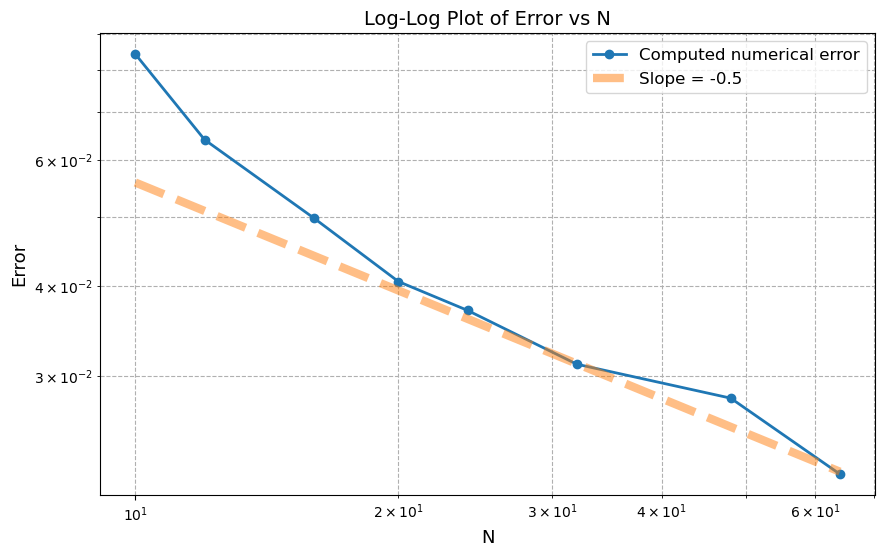

In [133]:
Nvec = np.array([10, 12, 16, 20, 24, 32, 48, 64])

### Recorded W^2_2 errors. 
loss_vec = np.sqrt(np.array([0.0071, 0.0041, 0.00248, 0.001649, 0.00137, 0.00097, 0.00078, 0.000479]))

# slope -0.5 reference line
N_ref = np.linspace(Nvec[0], Nvec[-1], 200)
C = loss_vec[0] * (Nvec[0] ** 0.5)-.09
ref_line = C * N_ref ** (-0.5)

plt.figure(figsize=(10, 6))
plt.loglog(Nvec, loss_vec, marker='o', linewidth=2, label='Computed numerical error')
plt.loglog(N_ref, ref_line, '--', linewidth=6, label='Slope = -0.5',alpha=0.5)
plt.grid(True, which='both', linestyle='--')
plt.xlabel('N', fontsize=13)
plt.ylabel('Error', fontsize=13)
plt.title('Log-Log Plot of Error vs N', fontsize=14)
plt.legend(fontsize=12)
#plt.savefig('convergence_plot.png')
plt.show()

### Checking the statistics

In [124]:
N=50;
M=int(0.2*N**(1+2))
X=torch.tensor(np.random.normal(scale=0.7,size=(M,1)),dtype=datatype) ## scale sets the std. 

sde=SDE_eps(N,X,1e-7)

In [125]:
Msamples=10000  ##6000
Xlist_temp=[]
x0=torch.zeros(1)
for i in range(Msamples):
    xx1=sde.forward(x0)
    Xlist_temp.append(xx1)
Xg=torch.stack(Xlist_temp)

In [126]:
Xout=Xg.squeeze().detach().numpy()
true_Xout=np.random.normal(scale=0.7,size=(Msamples))

In [127]:
from scipy import stats

In [128]:
ks_stat_2samp, ks_pvalue_2samp = stats.ks_2samp(Xout, true_Xout)
print(f"Two-sample KS Test - Statistic: {ks_stat_2samp:.4f}, p-value: {ks_pvalue_2samp:.4f}")
## p-value large, there is no evidence to reject that they come from the same distribution. 

Two-sample KS Test - Statistic: 0.0079, p-value: 0.9139


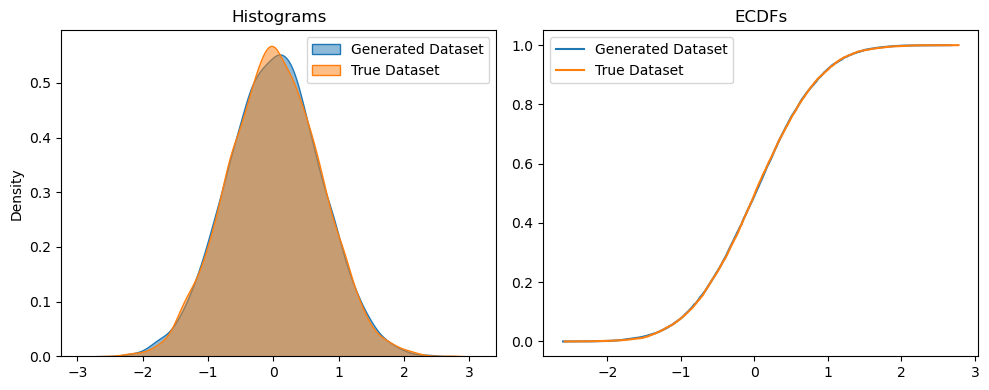

In [129]:
# Visualization
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
#plt.hist(Xout, alpha=0.7, label='Generated Dataset', bins=15)
#plt.hist(true_Xout, alpha=0.7, label='True Dataset', bins=15)
sns.kdeplot(Xout, label='Generated Dataset', fill=True, alpha=0.5)
sns.kdeplot(true_Xout, label='True Dataset', fill=True, alpha=0.5)
plt.legend()
plt.title('Histograms')

plt.subplot(1, 2, 2)
ecdf1 = np.sort(Xout)
ecdf2 = np.sort(true_Xout)
y1 = np.arange(1, len(ecdf1)+1) / len(ecdf1)
y2 = np.arange(1, len(ecdf2)+1) / len(ecdf2)
plt.plot(ecdf1, y1, label='Generated Dataset')
plt.plot(ecdf2, y2, label='True Dataset')
plt.legend()
plt.title('ECDFs')

plt.tight_layout()
#plt.savefig('Comparison_10000samples_N50.png')
#plt.show()

In [130]:
res = stats.anderson_ksamp([Xout,true_Xout])

In [131]:
res.statistic, res.pvalue
### Cannot reject the null hypothesis at the 5% level that they come from the same distributions

(np.float64(-0.9762049901450185), np.float64(0.25))